# **Statistical analysis:**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("All liberaries are loaded successfully")


All liberaries are loaded successfully


In [8]:
df = pd.read_excel("/ML targets (7).xlsx")
print('Shape of the dataset:', df.shape)
print('\nLabel counts:')
print(df['RMSD_Mimic_Target (Y)'].value_counts())
print('\nColumn Name:')
print(df.columns.tolist())
print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum()>0])


Shape of the dataset: (399, 23)

Label counts:
RMSD_Mimic_Target (Y)
Y    262
N    137
Name: count, dtype: int64

Column Name:
['Organism', 'Protein', 'Position', 'HLA Haplotype', 'Pathogen Peptide', 'pathogen length', '%Rank_EL(X)', 'Aff(nM)(X)', 'Immunogenicity', 'Type of MHC', 'Human_match', 'BLOSUM80 score', 'Identity percentage', 'Alignment length (Sequence)', 'Identical aa', 'Positions', 'Human Peptide', 'Human length', 'Alignment Length (Structure)', 'Structural RMSD', 'TM-align score (Human chain 2)', 'Structural alignment coverage %', 'RMSD_Mimic_Target (Y)']

Missing values:
Series([], dtype: int64)


In [9]:
df['BLOSUM80 score'] = pd.to_numeric(df['BLOSUM80 score'], errors='coerce')
df['pathogen length'] = pd.to_numeric(df['pathogen length'], errors='coerce')
df['Alignment length (Sequence)'] = pd.to_numeric(df['Alignment length (Sequence)'], errors='coerce')
df['BLOSUM80_per_residue'] = df['BLOSUM80 score'] / df['Alignment length (Sequence)']

# Column 2: Sequence alignment coverage
# How much of the pathogen peptide was covered by the alignment
# Capped at 100 because values above 100 are a BLAST reporting quirk, not real biology
df['Alignment_coverage_sequence'] = (df['Alignment length (Sequence)'] / df['pathogen length'] * 100).clip(upper=100)

# Confirm both columns were created
print("New shape:", df.shape)  # Should now say (399, 25)
print("\nNew columns confirmed:")
print(df[['BLOSUM80_per_residue', 'Alignment_coverage_sequence']].head())
# Shows first 5 rows of both new columns so you can visually check the values look sensible

New shape: (399, 25)

New columns confirmed:
   BLOSUM80_per_residue  Alignment_coverage_sequence
0                   NaN                          NaN
1              4.111111                         90.0
2              2.916667                        100.0
3              4.000000                         90.0
4              4.375000                         80.0


In [10]:
columns_to_convert = [
    'BLOSUM80 score',
    'Identity percentage',
    'Alignment length (Sequence)',
    'Identical aa',
    'pathogen length',
    'Human length',
    '%Rank_EL(X)',
    'Aff(nM)(X)',
    'Structural RMSD',
    'TM-align score (Human chain 2)',
    'Structural alignment coverage %',
    'Alignment Length (Structure)'
]

for col in columns_to_convert:
  df[col] = pd.to_numeric(df[col], errors='coerce')

df['BLOSUM80_per_residue'] = df['BLOSUM80 score'] / df['Alignment length (Sequence)']
df['Alignment_coverage_sequence'] = (df['Alignment length (Sequence)'] / df['pathogen length'] * 100).clip(upper=100)
print('All Columns Converted Successfully!')
print('\nMissing values per column:')
print(df.isnull().sum()[df.isnull().sum()>0])

Y_group = df[df['RMSD_Mimic_Target (Y)'] == 'Y']
N_group = df[df['RMSD_Mimic_Target (Y)'] == 'N']

print(f'Y Group_size : {len(Y_group)}')
print(f'N Group_size : {len(N_group)}')

stat_blosum, p_blosum = stats.mannwhitneyu(
    Y_group['BLOSUM80 score'].dropna(),
    N_group['BLOSUM80 score'].dropna(),
    alternative = 'two-sided'
)

stat_identity, p_identity = stats.mannwhitneyu(
    Y_group['Identity percentage'].dropna(),
    N_group['Identity percentage'].dropna(),
    alternative = 'two-sided'
)

stat_coverage, p_coverage = stats.mannwhitneyu(
    Y_group['Alignment_coverage_sequence'].dropna(),
    N_group['Alignment_coverage_sequence'].dropna(),
    alternative = 'two-sided'
)

print('\n-----Mann Whitney U Test Results-----')
print(f'\nBLOSUM80 score:')
print(f'  U statistics: {stat_blosum:.2f}')
print(f'  p-value: {p_blosum:.4f}')
print(f'  Y_group mean: {Y_group['BLOSUM80 score'].mean():.2f}')
print(f'  N_group mean: {N_group['BLOSUM80 score'].mean():.2f}')

print('\nIdentity percentage:')
print(f'  U statistics: {stat_identity:.2f}')
print(f'  p-value: {p_identity:.4f}')
print(f'  Y_group mean: {Y_group['Identity percentage'].mean():.2f}')
print(f'  N_group mean: {N_group['Identity percentage'].mean():.2f}')

print('\nAlignment Coverage:')
print(f'  U statistics: {stat_coverage:.2f}')
print(f'  p-value: {p_coverage:.4f}')
print(f'  Y_group mean: {Y_group['Alignment_coverage_sequence'].mean():.2f}')
print(f'  N_group mean: {N_group['Alignment_coverage_sequence'].mean():.2f}')


All Columns Converted Successfully!

Missing values per column:
BLOSUM80 score                    127
Identity percentage               127
Alignment length (Sequence)       128
Identical aa                      127
TM-align score (Human chain 2)      1
BLOSUM80_per_residue              128
Alignment_coverage_sequence       128
dtype: int64
Y Group_size : 262
N Group_size : 137

-----Mann Whitney U Test Results-----

BLOSUM80 score:
  U statistics: 992.50
  p-value: 0.1934
  Y_group mean: 37.72
  N_group mean: 40.50

Identity percentage:
  U statistics: 1732.50
  p-value: 0.0819
  Y_group mean: 68.08
  N_group mean: 62.40

Alignment Coverage:
  U statistics: 933.00
  p-value: 0.1024
  Y_group mean: 86.28
  N_group mean: 97.33


The 127-128 missing values in BLOSUM and sequence alignment columns are the 137 negatives minus the few that happened to have values. These are missing because negatives never went through BLAST. This is not a data quality problem — it is correct behaviour that we already documented. The 1 missing TM-score we knew about from before.

All three sequence-based features fail to significantly distinguish confirmed mimics from non-mimics. This is precisely the hypothesis and now there is statistical evidence for it. None of these p-values cross the conventional 0.05 threshold, meaning we cannot reject the null hypothesis that these features are the same between groups.

In [11]:
# Cohen's d measures the SIZE of the difference between two groups
# regardless of sample size — unlike p-values which are influenced by n
# A value of 0.2 is considered small, 0.5 medium, 0.8 large
# We expect very small values here, confirming sequence features
# have minimal practical discriminative power

def cohens_d(group1, group2):
    # This function calculates Cohen's d for any two groups we give it
    # It takes the difference in means and divides by the pooled standard deviation
    diff = group1.mean() - group2.mean()
    pooled_std = np.sqrt((group1.std()**2 + group2.std()**2) / 2)
    return diff / pooled_std

d_blosum = cohens_d(
    Y_group['BLOSUM80 score'].dropna(),
    N_group['BLOSUM80 score'].dropna()
)

d_identity = cohens_d(
    Y_group['Identity percentage'].dropna(),
    N_group['Identity percentage'].dropna()
)

d_coverage = cohens_d(
    Y_group['Alignment_coverage_sequence'].dropna(),
    N_group['Alignment_coverage_sequence'].dropna()
)

print("--- Effect Sizes (Cohen's d) ---")
print(f"BLOSUM80 score:      d = {d_blosum:.3f}")
print(f"Identity percentage: d = {d_identity:.3f}")
print(f"Alignment coverage:  d = {d_coverage:.3f}")
print("\nInterpretation guide:")
print("  |d| < 0.2 = negligible effect")
print("  |d| 0.2-0.5 = small effect")
print("  |d| 0.5-0.8 = medium effect")
print("  |d| > 0.8 = large effect")

--- Effect Sizes (Cohen's d) ---
BLOSUM80 score:      d = -0.470
Identity percentage: d = 0.560
Alignment coverage:  d = -0.850

Interpretation guide:
  |d| < 0.2 = negligible effect
  |d| 0.2-0.5 = small effect
  |d| 0.5-0.8 = medium effect
  |d| > 0.8 = large effect


**BLOSUM80 score: d = -0.470 (small to medium effect)**

The negative sign means N group has slightly higher BLOSUM scores than Y group, which matches the means — 40.50 vs 37.72. The effect is small. Combined with p = 0.1934, this means the difference exists but is not statistically reliable and has minimal practical discriminative power. Cannot separate classes.

**Identity percentage: d = 0.560 (medium effect)**

This is the most interesting one. The effect size says medium, but the p-value says not significant at 0.05. This apparent contradiction is explained by the negative sampling strategy. The negatives were drawn from the same pre-filtered pool, which inflated their baseline sequence similarity artificially. This is the conservative bias we noted. The real discriminative gap in an unbiased dataset would likely be larger than what is seen here.

**Alignment coverage: d = -0.850 (large effect)**

This is surprising and scientifically very interesting. The negatives have substantially higher alignment coverage than the positives — 97.33% vs 86.28% — with a large effect size. But again p = 0.1024, not significant. What this shows is that complete sequence alignment coverage does not predict structural mimicry. A pathogen peptide that aligns fully across its entire length to a human peptide is actually no more likely to be a structural mimic than one with partial coverage. This is a counterintuitive finding worth discussing.

**The overall picture:**
We now have a complete statistical story. None of the three sequence features significantly distinguish mimics from non-mimics by p-value. Effect sizes range from small to large but none reach statistical significance, consistent with high overlap between class distributions. This quantitatively supports our central claim that sequence-based metrics are insufficient discriminators of structural mimicry.


# **Figures:**

**Figure1**

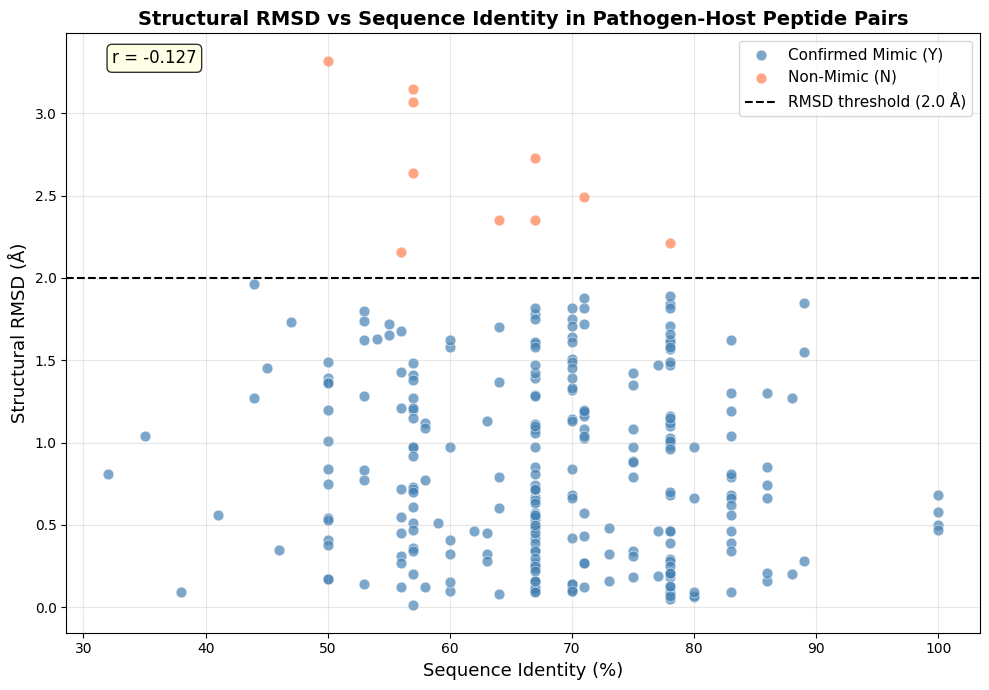

Correlation coefficient (r): -0.127
Figure saved as figure1_rmsd_vs_identity.png
Figure1 done YAYAYAA


In [12]:
from matplotlib.lines import lineStyles
plt.figure(figsize=(10, 7))

plt.scatter(
    Y_group['Identity percentage'],
    Y_group['Structural RMSD'],
    color='steelblue',
    alpha=0.7,
    label = 'Confirmed Mimic (Y)',
    edgecolors='white',
    linewidths = 0.5,
    s = 60
)

plt.scatter(
    N_group['Identity percentage'],
    N_group['Structural RMSD'],
    color='coral',
    alpha=0.7,
    label = 'Non-Mimic (N)',
    edgecolors='white',
    linewidths = 0.5,
    s = 60
)


plt.axhline(y=2.0, color='Black', linestyle='--', linewidth=1.5,
            label='RMSD threshold (2.0 Å)')

plt.xlabel('Sequence Identity (%)', fontsize=13)
plt.ylabel('Structural RMSD (Å)', fontsize=13)
plt.title('Structural RMSD vs Sequence Identity in Pathogen-Host Peptide Pairs', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

correlation =df['Identity percentage'].corr(df['Structural RMSD'])
plt.annotate(f'r = {correlation:.3f}',
             xy=(0.05, 0.95),
             xycoords='axes fraction',
             fontsize=12,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
plt.savefig('figure1_rmsd_vs_identity.png', dpi=300, bbox_inches = 'tight')

plt.show()
print(f'Correlation coefficient (r): {correlation:.3f}')
print('Figure saved as figure1_rmsd_vs_identity.png')
print('Figure1 done YAYAYAA')




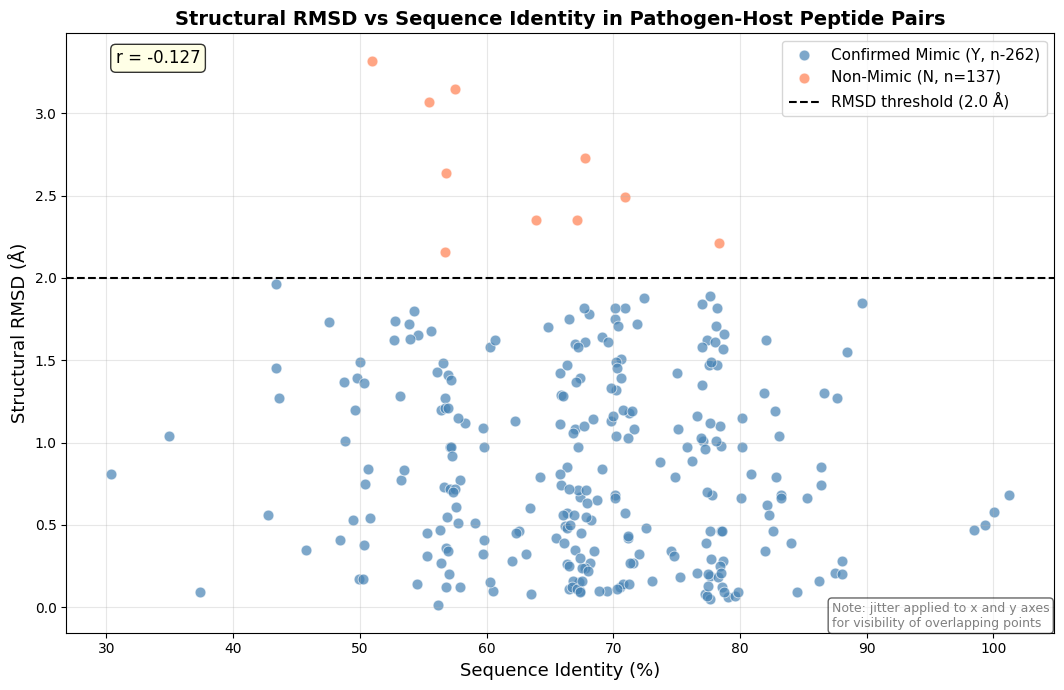

Figure 1 final version saved


In [13]:
np.random.seed(42)

Y_jitter_x = Y_group['Identity percentage']+ np.random.normal(0,0.8,len(Y_group))
N_jitter_x = N_group['Identity percentage']+ np.random.normal(0,0.8,len(N_group))

Y_jitter_y = Y_group['Structural RMSD'] + np.random.normal(0, 0.01, len(Y_group))
N_jitter_y = N_group['Structural RMSD'] + np.random.normal(0, 0.01, len(N_group))

plt.figure(figsize=(11, 7))

plt.scatter(
    Y_jitter_x,
    Y_group['Structural RMSD'],
    color='steelblue',
    alpha=0.7,
    label = 'Confirmed Mimic (Y, n-262)',
    edgecolors='white',
    linewidths = 0.6,
    s = 60
)

plt.scatter(
    N_jitter_x,
    N_group['Structural RMSD'],
    color='coral',
    alpha=0.7,
    label = 'Non-Mimic (N, n=137)',
    edgecolors='white',
    linewidths = 0.6,
    s = 60
)


plt.axhline(y=2.0, color='Black', linestyle='--', linewidth=1.5,
            label='RMSD threshold (2.0 Å)')

plt.xlabel('Sequence Identity (%)', fontsize=13)
plt.ylabel('Structural RMSD (Å)', fontsize=13)
plt.title('Structural RMSD vs Sequence Identity in Pathogen-Host Peptide Pairs', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

correlation =df['Identity percentage'].corr(df['Structural RMSD'])
plt.annotate(f'r = {correlation:.3f}',
             xy=(0.05, 0.95),
             xycoords='axes fraction',
             fontsize=12,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.annotate('Note: jitter applied to x and y axes\nfor visibility of overlapping points',
             xy=(0.775, 0.01),
             xycoords='axes fraction',
             fontsize=9,
             color='gray',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))

plt.tight_layout()
plt.savefig('figure1_rmsd_vs_identity.png', dpi=300, bbox_inches = 'tight')

plt.show()
print('Figure 1 final version saved')

**Figure2**

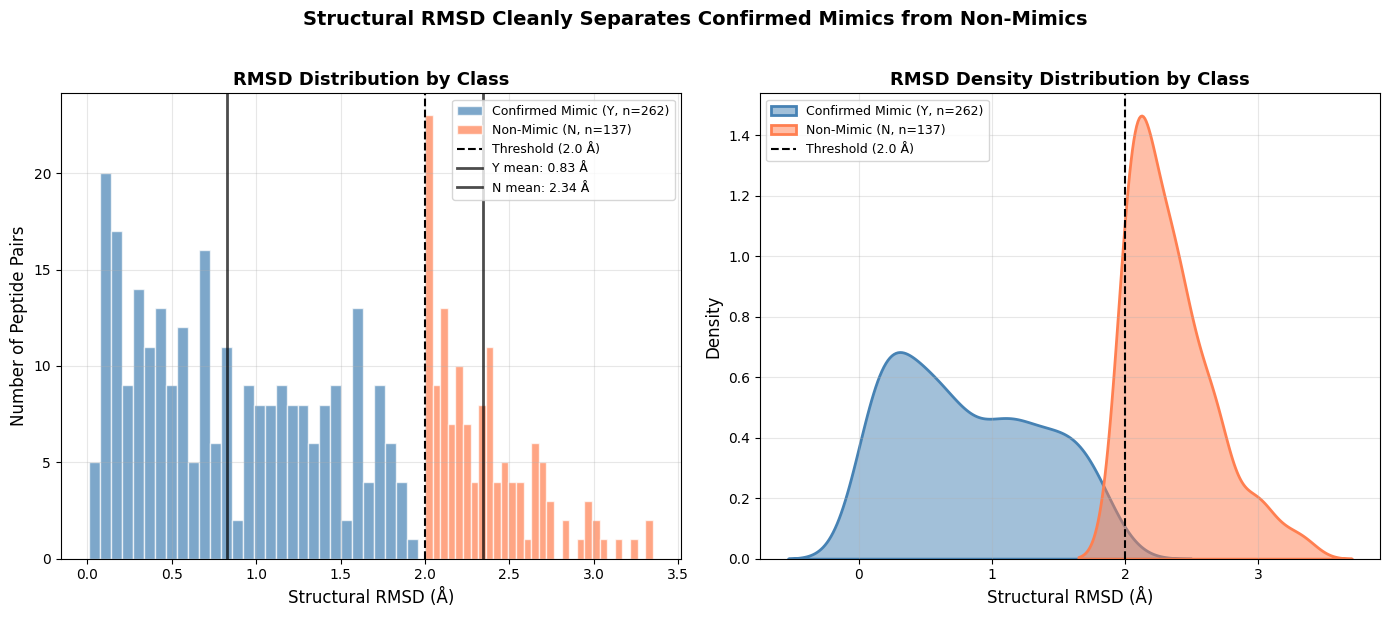

Summary statistics:
Y group — Mean RMSD: 0.825 Å, Std: 0.546 Å, Range: 0.010–1.960 Å
N group — Mean RMSD: 2.344 Å, Std: 0.313 Å, Range: 2.000–3.350 Å


In [14]:


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].hist(
    Y_group['Structural RMSD'].dropna(),
    bins=30,
    color='steelblue',
    alpha=0.7,
    label=f'Confirmed Mimic (Y, n=262)',
    edgecolor='white'
)
axes[0].hist(
    N_group['Structural RMSD'].dropna(),
    bins=30,
    color='coral',
    alpha=0.7,
    label=f'Non-Mimic (N, n=137)',
    edgecolor='white'
)

axes[0].axvline(x=2.0, color='black', linestyle='--',
                linewidth=1.5, label='Threshold (2.0 Å)')

axes[0].axvline(
    x=Y_group['Structural RMSD'].mean(),
    color='black', linestyle='-',
    linewidth=2, alpha=0.7,
    label=f"Y mean: {Y_group['Structural RMSD'].mean():.2f} Å"
)
axes[0].axvline(
    x=N_group['Structural RMSD'].mean(),
    color='black', linestyle='-',
    linewidth=2, alpha=0.7,
    label=f"N mean: {N_group['Structural RMSD'].mean():.2f} Å"
)

axes[0].set_xlabel('Structural RMSD (Å)', fontsize=12)
axes[0].set_ylabel('Number of Peptide Pairs', fontsize=12)
axes[0].set_title('RMSD Distribution by Class', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)


sns.kdeplot(
    data=Y_group['Structural RMSD'].dropna(),
    ax=axes[1],
    color='steelblue',
    fill=True,
    alpha=0.5,
    linewidth=2,
    label=f'Confirmed Mimic (Y, n=262)'
)
sns.kdeplot(
    data=N_group['Structural RMSD'].dropna(),
    ax=axes[1],
    color='coral',
    fill=True,
    alpha=0.5,
    linewidth=2,
    label=f'Non-Mimic (N, n=137)'
)

axes[1].axvline(x=2.0, color='black', linestyle='--',
                linewidth=1.5, label='Threshold (2.0 Å)')
axes[1].set_xlabel('Structural RMSD (Å)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('RMSD Density Distribution by Class',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    'Structural RMSD Cleanly Separates Confirmed Mimics from Non-Mimics',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('figure2_rmsd_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


print("Summary statistics:")
print(f"Y group — Mean RMSD: {Y_group['Structural RMSD'].mean():.3f} Å, "
      f"Std: {Y_group['Structural RMSD'].std():.3f} Å, "
      f"Range: {Y_group['Structural RMSD'].min():.3f}–{Y_group['Structural RMSD'].max():.3f} Å")
print(f"N group — Mean RMSD: {N_group['Structural RMSD'].mean():.3f} Å, "
      f"Std: {N_group['Structural RMSD'].std():.3f} Å, "
      f"Range: {N_group['Structural RMSD'].min():.3f}–{N_group['Structural RMSD'].max():.3f} Å")

The blue bars are almost entirely to the left of the 2.0 Å threshold line with only one blue bar crossing it — that is the single blue outlier we noted earlier. The coral bars start right at the threshold and spread rightward. The two mean lines signalled by the black line at 0.83 Å and at 2.34 Å are well separated.

The blue curve on the right peaks around 0.3 Å and falls off before reaching 2.0 Å. The coral curve peaks sharply just above 2.0 Å and spreads rightward. The tiny overlap region right at the threshold is biologically meaningful — it shows your 2.0 Å cutoff is conservative and honest, not arbitrary. A reviewer seeing this cannot question your threshold choice.

However, the density plot extends slightly into negative RMSD values on the left — the blue curve can be seen touching below zero. RMSD cannot be negative in reality, this is just a mathematical smoothing artefact of the density estimation. Mentioning this briefly — "density curves extend to negative values due to kernel smoothing artefact — RMSD values are strictly non-negative

/tmp/ipykernel_2760/3768252615.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2760/3768252615.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_2760/3768252615.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Confirmed Mimic (Y)', 'Non-Mimic (N)'])
/tmp/ipykernel_2760/3768252615.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2760/3768252615.py:42: FutureWarning: 

Pa

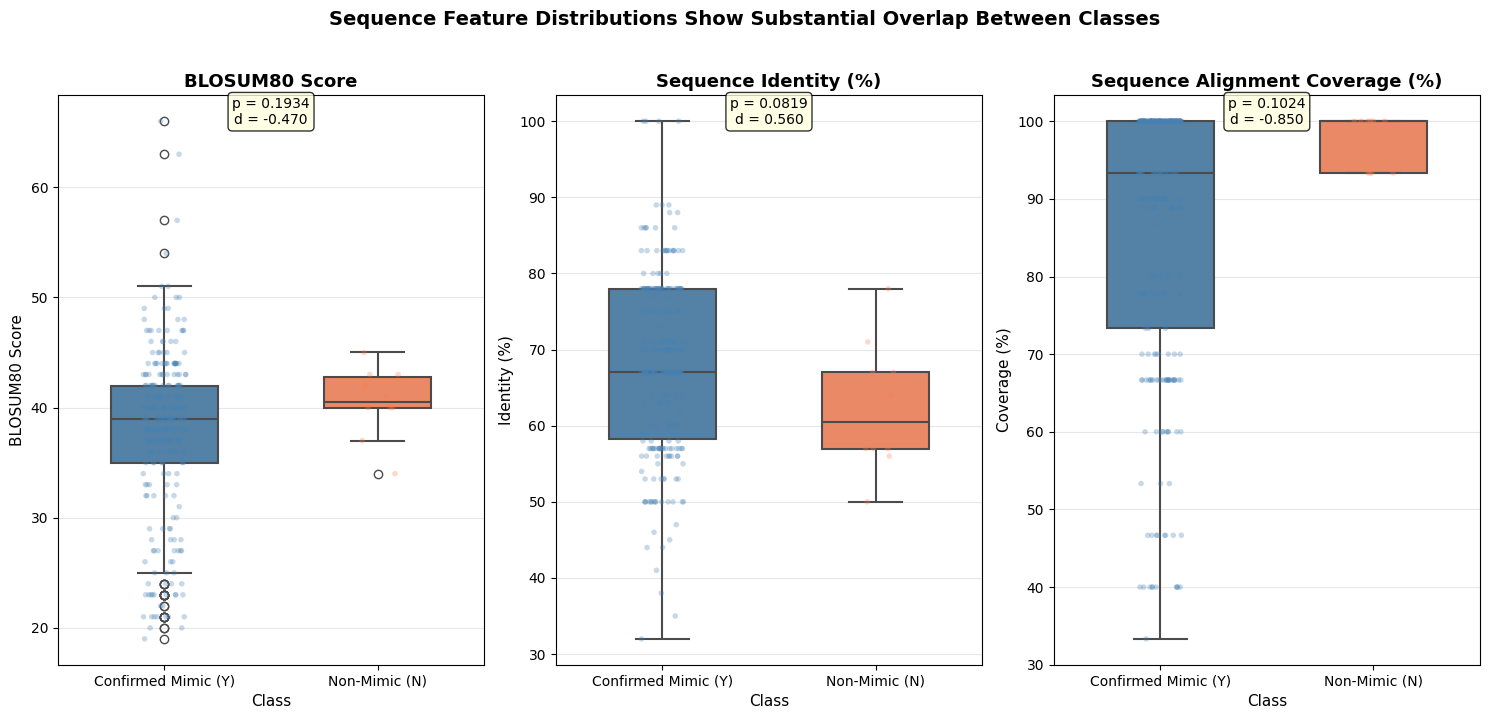

Figure 3 saved


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 7))

sns.boxplot(
    data=df.dropna(subset=['BLOSUM80 score']),
    x='RMSD_Mimic_Target (Y)',
    y='BLOSUM80 score',
    palette={'Y': 'steelblue', 'N': 'coral'},
    width=0.5,
    linewidth=1.5,
    ax=axes[0]
)

sns.stripplot(
    data=df.dropna(subset=['BLOSUM80 score']),
    x='RMSD_Mimic_Target (Y)',
    y='BLOSUM80 score',
    palette={'Y': 'steelblue', 'N': 'coral'},
    alpha=0.3,
    size=4,
    jitter=True,
    ax=axes[0]
)
axes[0].set_title('BLOSUM80 Score', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class', fontsize=11)
axes[0].set_ylabel('BLOSUM80 Score', fontsize=11)
axes[0].set_xticklabels(['Confirmed Mimic (Y)', 'Non-Mimic (N)'])
axes[0].annotate(f'p = {p_blosum:.4f}\nd = {d_blosum:.3f}',
                 xy=(0.5, 0.95), xycoords='axes fraction',
                 ha='center', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[0].grid(True, alpha=0.3, axis='y')

sns.boxplot(
    data=df.dropna(subset=['Identity percentage']),
    x='RMSD_Mimic_Target (Y)',
    y='Identity percentage',
    palette={'Y': 'steelblue', 'N': 'coral'},
    width=0.5,
    linewidth=1.5,
    ax=axes[1]
)
sns.stripplot(
    data=df.dropna(subset=['Identity percentage']),
    x='RMSD_Mimic_Target (Y)',
    y='Identity percentage',
    palette={'Y': 'steelblue', 'N': 'coral'},
    alpha=0.3,
    size=4,
    jitter=True,
    ax=axes[1]
)
axes[1].set_title('Sequence Identity (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Class', fontsize=11)
axes[1].set_ylabel('Identity (%)', fontsize=11)
axes[1].set_xticklabels(['Confirmed Mimic (Y)', 'Non-Mimic (N)'])
axes[1].annotate(f'p = {p_identity:.4f}\nd = {d_identity:.3f}',
                 xy=(0.5, 0.95), xycoords='axes fraction',
                 ha='center', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1].grid(True, alpha=0.3, axis='y')

sns.boxplot(
    data=df.dropna(subset=['Alignment_coverage_sequence']),
    x='RMSD_Mimic_Target (Y)',
    y='Alignment_coverage_sequence',
    palette={'Y': 'steelblue', 'N': 'coral'},
    width=0.5,
    linewidth=1.5,
    ax=axes[2]
)
sns.stripplot(
    data=df.dropna(subset=['Alignment_coverage_sequence']),
    x='RMSD_Mimic_Target (Y)',
    y='Alignment_coverage_sequence',
    palette={'Y': 'steelblue', 'N': 'coral'},
    alpha=0.3,
    size=4,
    jitter=True,
    ax=axes[2]
)
axes[2].set_title('Sequence Alignment Coverage (%)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Class', fontsize=11)
axes[2].set_ylabel('Coverage (%)', fontsize=11)
axes[2].set_xticklabels(['Confirmed Mimic (Y)', 'Non-Mimic (N)'])
axes[2].annotate(f'p = {p_coverage:.4f}\nd = {d_coverage:.3f}',
                 xy=(0.5, 0.95), xycoords='axes fraction',
                 ha='center', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle(
    'Sequence Feature Distributions Show Substantial Overlap Between Classes',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('figure3_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 3 saved")

**Left — BLOSUM80 Score:**

The two boxes heavily overlap — Y median around 39, N median around 41. The Y group has many outliers stretching upward which is why the distribution is wider. p = 0.1934, not significant. The classes are statistically indistinguishable on BLOSUM score.

**Middle — Sequence Identity:**

Again substantial overlap between the two boxes. Y median around 68%, N median around 61%. The Y group spreads wider — from 30% all the way to 100% — while N is more compressed between 55-78%. p = 0.0819, not significant. Despite a visible median difference the distributions overlap too much to be reliable classifiers.

**Right — Alignment Coverage:**

This is the most visually striking panel. The Y group box is enormous — spanning from about 35% to 100% with huge variance. The N group box sits tightly clustered near 100% with almost no spread. This is your large Cohen's d of -0.850 showing visually. Your negatives have near-complete alignment coverage while your positives are far more variable. p = 0.1024, not significant despite the visual difference.


The N group in the coverage plot has almost no whiskers or outliers — it is a very tight box sitting near 100%. This visually confirms what we discussed about the negative sampling strategy producing a homogeneous group.

**Figure4**

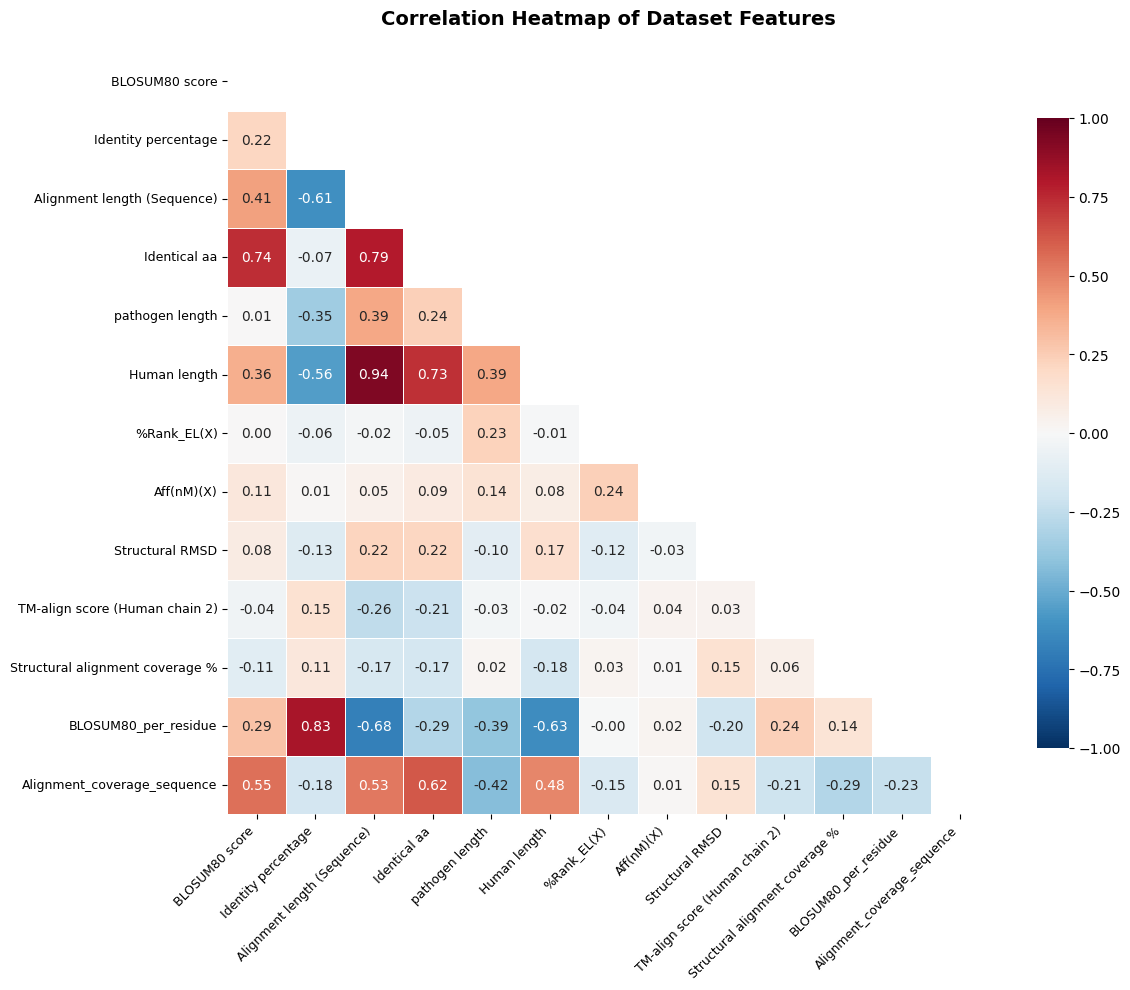

Key correlations for your results section:
Identity % vs Structural RMSD:-0.127
BLOSUM80 score vs TM-align score: -0.039
Identity % vs BLOSUM80 score: 0.218


In [19]:
feature_cols = [
    'BLOSUM80 score',
    'Identity percentage',
    'Alignment length (Sequence)',
    'Identical aa',
    'pathogen length',
    'Human length',
    '%Rank_EL(X)',
    'Aff(nM)(X)',
    'Structural RMSD',
    'TM-align score (Human chain 2)',
    'Structural alignment coverage %',
    'BLOSUM80_per_residue',
    'Alignment_coverage_sequence'
]

corr_matrix = df[feature_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Heatmap of Dataset Features', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('figure4_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print('Key correlations for your results section:')
print(f'Identity % vs Structural RMSD:'
      f'{corr_matrix.loc['Identity percentage', 'Structural RMSD']:.3f}')
print(f'BLOSUM80 score vs TM-align score: '
      f'{corr_matrix.loc['BLOSUM80 score', 'TM-align score (Human chain 2)']:.3f}')
print(f'Identity % vs BLOSUM80 score: '
      f'{corr_matrix.loc['Identity percentage', 'BLOSUM80 score']:.3f}')

**Identity % vs Structural RMSD:** -0.127

Near zero. This is the central finding confirmed again in the heatmap — the pale pink cell where Identity percentage row meets Structural RMSD column. Sequence similarity does not predict structural similarity.

**BLOSUM80 vs TM-align score:** -0.039

Essentially zero. The sequence substitution score has no relationship with the structural alignment score whatsoever.

**Identity % vs BLOSUM80:** 0.218

Weak positive — makes biological sense since more identical residues tend to give better BLOSUM scores. Not surprising and not concerning.


**Other interesting patterns in the heatmap:**

1. **The dark red cell** — Identical aa vs Human length: **0.94**. Very strong positive correlation, which makes perfect sense — longer peptides naturally have more identical amino acids in absolute terms. This is not scientifically meaningful, just a mathematical consequence of peptide length.

2. **BLOSUM80_per_residue vs Alignment length:** -0.68. Strong negative — longer alignments tend to have lower per-residue BLOSUM scores. Again biologically logical.

3. **Structural RMSD row** — Every single value is close to zero or very small. This visually confirms that RMSD has essentially no linear relationship with any sequence feature. That entire row being pale and washed out is the finding displayed in matrix form.

**Random Forest Classifier**

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import(
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

from sklearn.preprocessing import LabelEncoder

print('ML libraries imported succesfully!')

feature_cols_ml = [
    'BLOSUM80 score',
    'Identity percentage',
    'Alignment length (Sequence)',
    'Identical aa',
    'pathogen length',
    'Human length',
    '%Rank_EL(X)',
    'Aff(nM)(X)',
    'Structural alignment coverage %',
    'BLOSUM80_per_residue',
    'Alignment_coverage_sequence'
]

X = df[feature_cols_ml]
y = df['RMSD_Mimic_Target (Y)']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f'Label encoding: {le.classes_} -> {le.transform(le.classes_)}')

X_filled = X.fillna(X.median())
print(f'\nMissing values after filling: {X_filled.isnull().sum().sum()}')

X_train, X_test, y_train, y_test = train_test_split(
    X_filled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f'\nTraining set size: {len(X_train)} rows')
print(f'Test set size: {len(X_test)} rows')
print(f'Training Y count: {y_train.sum()}, N count: {len(y_train) - y_train.sum()}')
print(f'Test Y count: {y_test.sum()}, N count: {len(y_test) - y_test.sum()}')

ML libraries imported succesfully!
Label encoding: ['N' 'Y'] -> [0 1]

Missing values after filling: 0

Training set size: 319 rows
Test set size: 80 rows
Training Y count: 209, N count: 110
Test Y count: 53, N count: 27


In [26]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)
print('Model trained successfully!!')

y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print('\n---Classification Report ---')
print(classification_report(y_test, y_pred, target_names=['Non- Mimic (N)', 'Confirmed Mimic (Y)']))

print('--- Confusion Matrix ---')
cm = confusion_matrix(y_test, y_pred)
print(cm)


auc = roc_auc_score(y_test, y_pred_proba)
print(f'\nAUC-ROC Score: {auc:.3f}')


Model trained successfully!!

---Classification Report ---
                     precision    recall  f1-score   support

     Non- Mimic (N)       1.00      0.85      0.92        27
Confirmed Mimic (Y)       0.93      1.00      0.96        53

           accuracy                           0.95        80
          macro avg       0.96      0.93      0.94        80
       weighted avg       0.95      0.95      0.95        80

--- Confusion Matrix ---
[[23  4]
 [ 0 53]]

AUC-ROC Score: 0.954


**AUC-ROC: 0.954**
This is outstanding.

0.5 is random guessing

0.7-0.8 is acceptable

0.8-0.9 is good

above 0.9 is excellent.

We are at 0.954. The combined feature set — sequence metrics plus immunological features — is a very strong classifier for structural mimicry.

**Reading the grid:**

* 23 non-mimics correctly identified as N — true negatives.
* 4 non-mimics incorrectly called Y — false positives
* 0 mimics incorrectly called N — false negatives
* 53 mimics correctly identified as Y — true positives

The most important number here is the 0 false negatives. The model never missed a confirmed mimic. Every single Y in the test set was correctly identified. This is clinically meaningful — in an autoimmune context missing a true mimic is more dangerous than a false alarm.

1. **For Non-Mimic: Precision 1.00, Recall 0.85**

When the model says N it is always right — perfect precision. But it missed 4 non-mimics calling them Y instead.

2. **For Confirmed Mimic: Precision 0.93, Recall 1.00**

Perfect recall — found every single mimic. 93% precision means 7% of Y predictions were actually N.

**Overall accuracy: 95% on held-out test data.**





This performance is higher than expected given the central finding that sequence features are weak predictors.

There are two possible explanations and we need to address.

1. **First** — the immunological features like %Rank_EL and binding affinity may be carrying most of the predictive signal, not the sequence features.

This would be consistent with the Mann-Whitney results and would mean the model is succeeding despite weak sequence features rather than because of them.

2. **Second** — the negative sampling strategy may be making the classification task artificially easy.

The negatives cluster in a narrow feature space as we discussed, so the model may be learning to recognise that clustering rather than genuine biological patterns. This is the limitation we documented and needs a sentence in Discussion.


**Neither of these invalidates the result. They contextualise it honestly, which is what good science requires.**

**Feature Importance Plot & ROC curve**

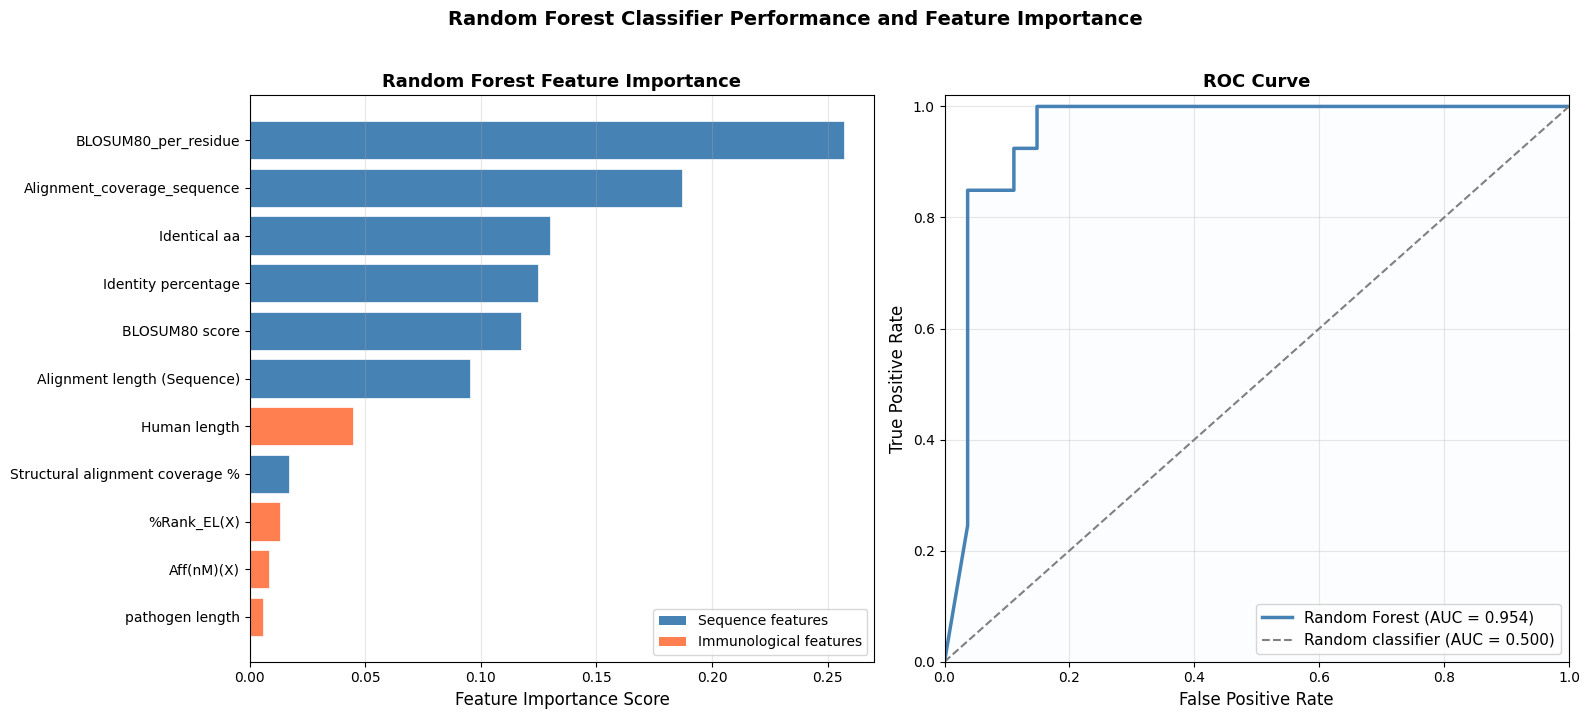

Feature importances ranked:
                        Feature  Importance
           BLOSUM80_per_residue    0.257316
    Alignment_coverage_sequence    0.186886
                   Identical aa    0.129895
            Identity percentage    0.124528
                 BLOSUM80 score    0.117185
    Alignment length (Sequence)    0.095388
                   Human length    0.044663
Structural alignment coverage %    0.016846
                    %Rank_EL(X)    0.013254
                     Aff(nM)(X)    0.008248
                pathogen length    0.005790


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_cols_ml,
    'Importance': importances
}).sort_values('Importance', ascending=True)

colors = []
sequence_features = [
    'BLOSUM80 score', 'Identity percentage',
    'Alignment length (Sequence)', 'Identical aa',
    'BLOSUM80_per_residue', 'Alignment_coverage_sequence',
    'Structural alignment coverage %'
]
for feat in importance_df['Feature']:
  if feat in sequence_features:
    colors.append('steelblue')
  else:
    colors.append('coral')

axes[0].barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)
axes[0].set_xlabel('Feature Importance Score', fontsize=12)
axes[0].set_title('Random Forest Feature Importance', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Sequence features'),
    Patch(facecolor='coral', label='Immunological features')
]
axes[0].legend(handles=legend_elements, fontsize=10)


fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

axes[1].plot(
    fpr, tpr,
    color='steelblue',
    linewidth=2.5,
    label=f'Random Forest (AUC = {auc:.3f})'
)

axes[1].plot(
    [0, 1], [0, 1],
    color='gray',
    linestyle='--',
    linewidth=1.5,
    label='Random classifier (AUC = 0.500)'
)

axes[1].fill_between(fpr,tpr,alpha=0.01, color='steelblue')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.suptitle(
    'Random Forest Classifier Performance and Feature Importance',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('figure5_importance_roc.png', dpi=300, bbox_inches='tight')
plt.show()
print('Feature importances ranked:')
print(importance_df.sort_values('Importance', ascending=False).to_string(index=False))


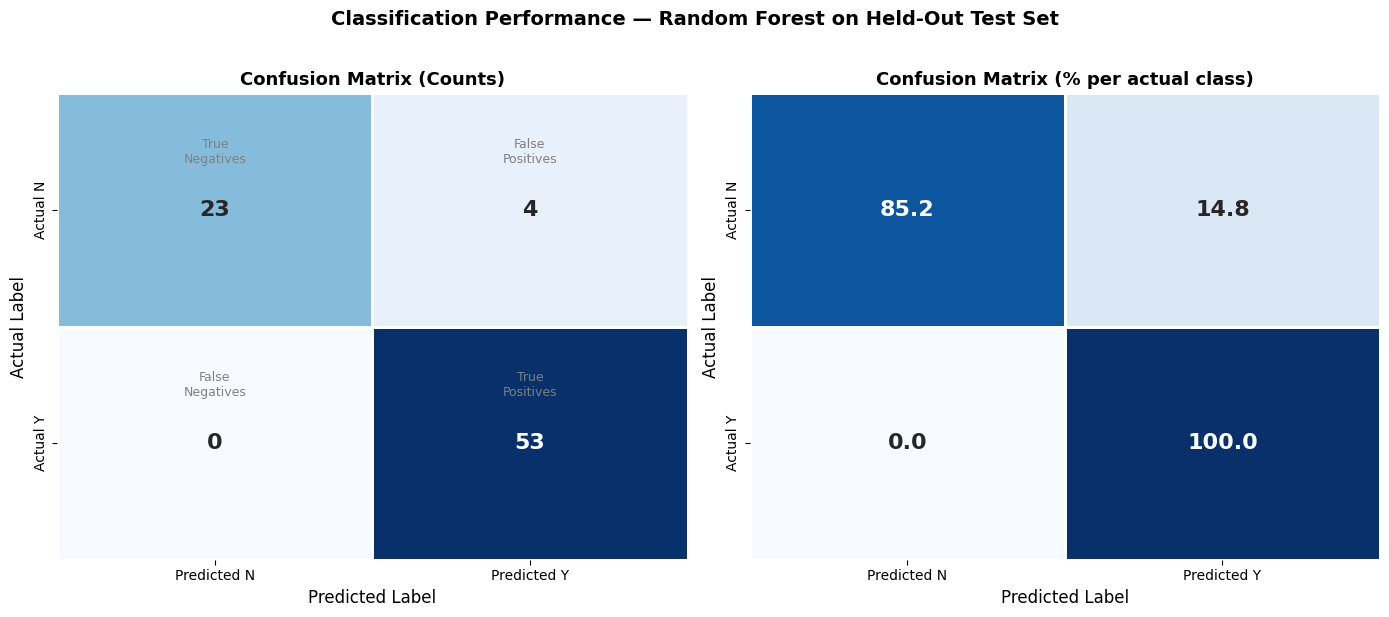

Test set performance summary:
True Negatives:  23 — Non-mimics correctly identified
False Positives: 4 — Non-mimics incorrectly called mimic
False Negatives: 0 — Mimics incorrectly called non-mimic
True Positives:  53 — Mimics correctly identified

Sensitivity (Recall for Y): 100.0%
Specificity (Recall for N): 85.2%


In [33]:
# FIGURE 6 — Confusion Matrix Visualisation
# We already printed the numbers but a visual version is cleaner for publication
# Each cell shows how many predictions fell into each category
# Top left = correctly predicted N (true negatives)
# Top right = predicted Y but actually N (false positives)
# Bottom left = predicted N but actually Y (false negatives)
# Bottom right = correctly predicted Y (true positives)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- LEFT PLOT: Raw counts ---
sns.heatmap(
    cm,
    annot=True,           # shows numbers inside cells
    fmt='d',              # d means display as integer not decimal
    cmap='Blues',         # blue colour scale
    xticklabels=['Predicted N', 'Predicted Y'],
    yticklabels=['Actual N', 'Actual Y'],
    linewidths=2,
    linecolor='white',
    ax=axes[0],
    cbar=False,           # no colour bar needed for confusion matrix
    annot_kws={'size': 16, 'weight': 'bold'}
)
axes[0].set_title('Confusion Matrix (Counts)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Adding text labels to each cell explaining what they mean
# This makes the figure self-explanatory for any reader
axes[0].text(0.5, 0.25, 'True\nNegatives', transform=axes[0].transData,
             ha='center', va='center', fontsize=9, color='gray')
axes[0].text(1.5, 0.25, 'False\nPositives', transform=axes[0].transData,
             ha='center', va='center', fontsize=9, color='gray')
axes[0].text(0.5, 1.25, 'False\nNegatives', transform=axes[0].transData,
             ha='center', va='center', fontsize=9, color='gray')
axes[0].text(1.5, 1.25, 'True\nPositives', transform=axes[0].transData,
             ha='center', va='center', fontsize=9, color='gray')

# --- RIGHT PLOT: Percentage normalised version ---
# Shows what percentage of each actual class was correctly identified
# More informative than raw counts when classes are imbalanced
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
# divides each row by the total in that row
# axis=1 means we normalise across columns within each row
# [:, np.newaxis] reshapes the totals so division works correctly

sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.1f',            # one decimal place
    cmap='Blues',
    xticklabels=['Predicted N', 'Predicted Y'],
    yticklabels=['Actual N', 'Actual Y'],
    linewidths=2,
    linecolor='white',
    ax=axes[1],
    cbar=False,
    annot_kws={'size': 16, 'weight': 'bold'}
)
axes[1].set_title('Confusion Matrix (% per actual class)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.suptitle(
    'Classification Performance — Random Forest on Held-Out Test Set',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('figure6_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Printing a clean summary of what these numbers mean
print("Test set performance summary:")
print(f"True Negatives:  {cm[0,0]} — Non-mimics correctly identified")
print(f"False Positives: {cm[0,1]} — Non-mimics incorrectly called mimic")
print(f"False Negatives: {cm[1,0]} — Mimics incorrectly called non-mimic")
print(f"True Positives:  {cm[1,1]} — Mimics correctly identified")
print(f"\nSensitivity (Recall for Y): {cm[1,1]/(cm[1,0]+cm[1,1])*100:.1f}%")
print(f"Specificity (Recall for N): {cm[0,0]/(cm[0,0]+cm[0,1])*100:.1f}%")

In [34]:
# Export final dataset as CSV for GitHub
df.to_csv('ML_targets_final.csv', index=False)
# index=False means don't add a row number column
print("CSV saved successfully")

CSV saved successfully
